In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import os, sys


def get_dir_n_levels_up(path, n):
    # Go up n levels from the given path
    for _ in range(n):
        path = os.path.dirname(path)
    return path

proj_root = get_dir_n_levels_up(os.path.abspath("__file__"), 3)
sys.path.append(proj_root)

,seed,N,v_L1_final,A_Fro_final,A_MAE_final,mean_oracle_end,mean_learn_end,mean_noc_end,mean_gap_to_oracle_end,mean_err_avg,mean_err_max,vx_gap_to_oracle_end,vx_err_avg,vx_err_max
0,0,15,0.233419,2.035097,0.063601,0.613426,0.612669,0.364735,0.000757,0.000254,0.000757,0.000446,0.000260,0.000748
1,1,15,0.287302,1.489593,0.051445,0.617581,0.603602,0.379051,0.013978,0.008535,0.013978,0.014345,0.009316,0.014345
2,2,15,0.264516,1.122472,0.039039,0.632427,0.626137,0.379802,0.006290,0.005163,0.008962,0.006031,0.004958,0.009054
3,3,15,0.213446,1.079662,0.036557,0.627068,0.618948,0.388790,0.008120,0.006511,0.011464,0.008146,0.006759,0.012502
4,4,15,0.419452,1.066833,0.032915,0.635532,0.594676,0.347420,0.040856,0.021556,0.040856,0.046499,0.029969,0.048571
5,5,15,0.416407,1.473684,0.051456,0.668751,0.625121,0.424340,0.043630,0.021279,0.043630,0.041936,0.019884,0.041936
6,6,15,0.606748,1.294585,0.041143,0.650405,0.607281,0.369122,0.043125,0.023849,0.043125,0.051444,0.033713,0.051769
7,7,15,0.189758,1.280957,0.044435,0.622755,0.607382,0.395018,0.015373,0.009837,0.017155,0.015480,0.010632,0.017906
8,8,15,0.274079,1.419504,0.049587,0.624608,0.615222,0.393937,0.009386,0.004683,0.009386,0.009407,0.004941,0.009407
9,9,15,0.280922,1.729286,0.057004,0.608649,0.605727,0.368423,0.002922,0.001415,0.002922,0.002877,0.001422,0.002877



=== Aggregate (across seeds) ===


,count,mean,std,min,25%,50%,75%,max
v_L1_final,10.0,0.318605,0.126924,0.189758,0.241194,0.277501,0.384131,0.606748
A_Fro_final,10.0,1.399167,0.305783,1.066833,1.162093,1.357044,1.485616,2.035097
A_MAE_final,10.0,0.046718,0.009620,0.032915,0.039565,0.047011,0.051454,0.063601
mean_gap_to_oracle_end,10.0,0.018444,0.017209,0.000757,0.006747,0.011682,0.034486,0.043630
mean_err_avg,10.0,0.010308,0.008732,0.000254,0.004803,0.007523,0.018419,0.023849
vx_gap_to_oracle_end,10.0,0.019661,0.019284,0.000446,0.006560,0.011876,0.035322,0.051444
vx_err_avg,10.0,0.012185,0.011747,0.000260,0.004945,0.008037,0.017571,0.033713


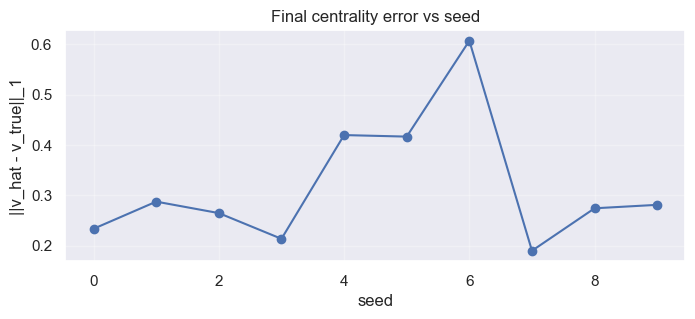

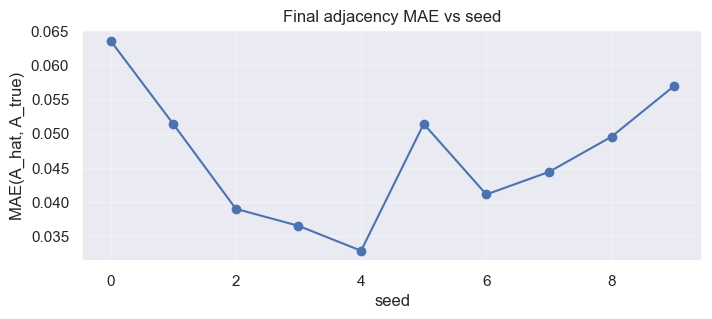

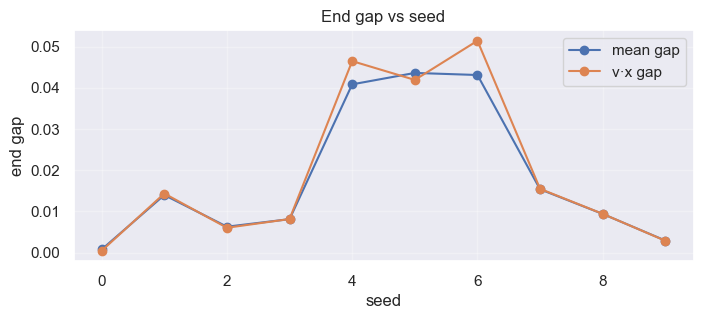

In [15]:
# =========================================================
# Multi-seed experiment (10 seeds) — collect metrics only
# =========================================================

import matplotlib.pyplot as plt

# Your identification + control pieces (from your repo)

from opinion_dynamics.experiments.online import run_multi_seed_experiment, run_single_seed_experiment
# from opinion_dynamics.experiments.rollouts import rollout_with_policy_intermediate
# from opinion_dynamics.experiments.metrics import graph_sanity


# =========================================================
# Run it
# =========================================================
df = run_multi_seed_experiment(
    seeds=range(10),
    B_campaign=1.0,
    num_campaigns_total=5,
    lr=1e-3,
    l2_lambda=0.0,
    device="cpu",
    update_A_each_campaign=True,
    suppress_fit_logs=True,
)

display(df)

print("\n=== Aggregate (across seeds) ===")
cols = ["v_L1_final","A_Fro_final","A_MAE_final","mean_gap_to_oracle_end","mean_err_avg","vx_gap_to_oracle_end","vx_err_avg"]
display(df[cols].describe().T)

# =========================================================
# Quick plots to inspect variability across seeds
# (matplotlib default colors as requested)
# =========================================================
plt.figure(figsize=(8,3))
plt.plot(df["seed"], df["v_L1_final"], marker="o")
plt.xlabel("seed"); plt.ylabel("||v_hat - v_true||_1")
plt.title("Final centrality error vs seed")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8,3))
plt.plot(df["seed"], df["A_MAE_final"], marker="o")
plt.xlabel("seed"); plt.ylabel("MAE(A_hat, A_true)")
plt.title("Final adjacency MAE vs seed")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8,3))
plt.plot(df["seed"], df["mean_gap_to_oracle_end"], marker="o", label="mean gap")
plt.xlabel("seed"); plt.ylabel("end gap")
plt.title("End gap vs seed")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

=== METRICS ===
{'seed': 6, 'N': 15, 'v_L1_final': 0.6099919752112599, 'A_Fro_final': 1.339401942424364, 'A_MAE_final': 0.04278941284033602, 'mean_oracle_end': 0.6504051933351345, 'mean_learn_end': 0.6072805271242265, 'mean_noc_end': 0.3691217017305383, 'mean_gap_to_oracle_end': 0.043124666210907936, 'mean_err_avg': 0.023848633271427878, 'mean_err_max': 0.043124666210907936, 'vx_gap_to_oracle_end': 0.05144357099963248, 'vx_err_avg': 0.033713256604145724, 'vx_err_max': 0.05176947393017395}

=== GRAPH SANITY (TRUE) ===
diag_max: 0.0
row_sum_min: 0.9999999999999998
row_sum_mean: 1.0
row_sum_max: 1.0
asym: 1.053195071273723
edges: 38
sink_sizes: [11]
has_singleton_sink: False

=== GRAPH SANITY (LEARNED FINAL) ===
diag_max: 0.0
row_sum_min: 0.9999998910934664
row_sum_mean: 1.000000003077245
row_sum_max: 1.0000001050066203
asym: 1.1428607842109608
edges: 210
sink_sizes: [15]
has_singleton_sink: False


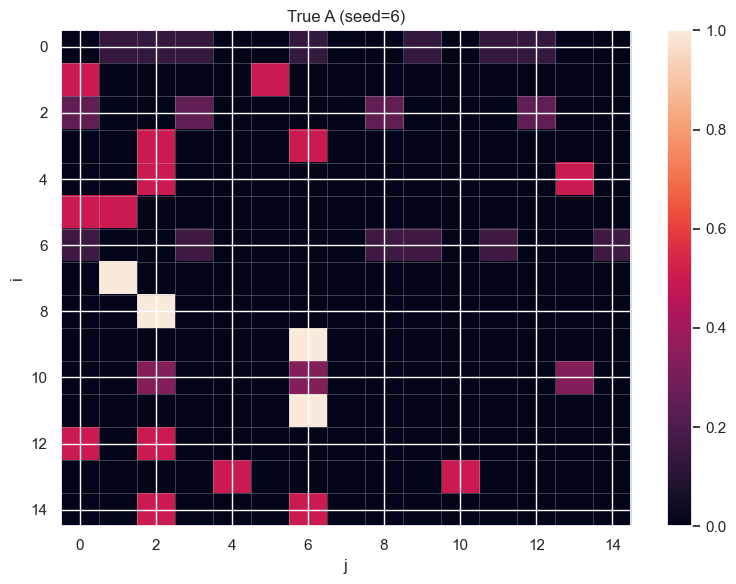

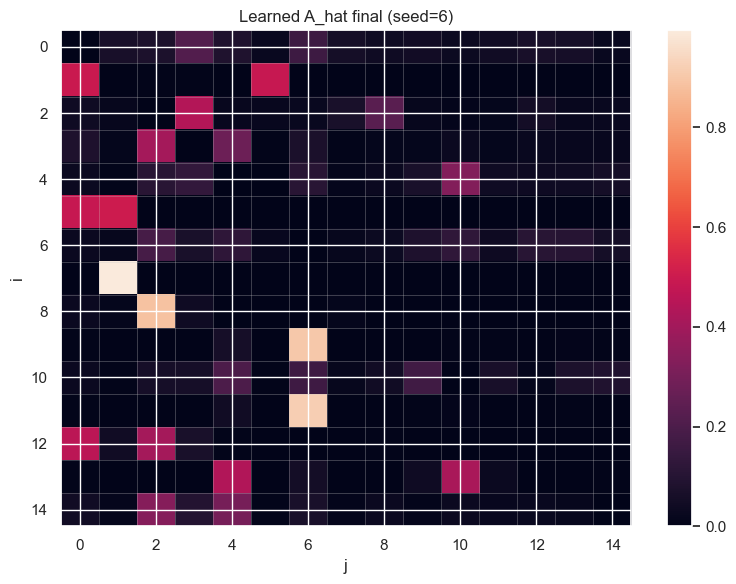

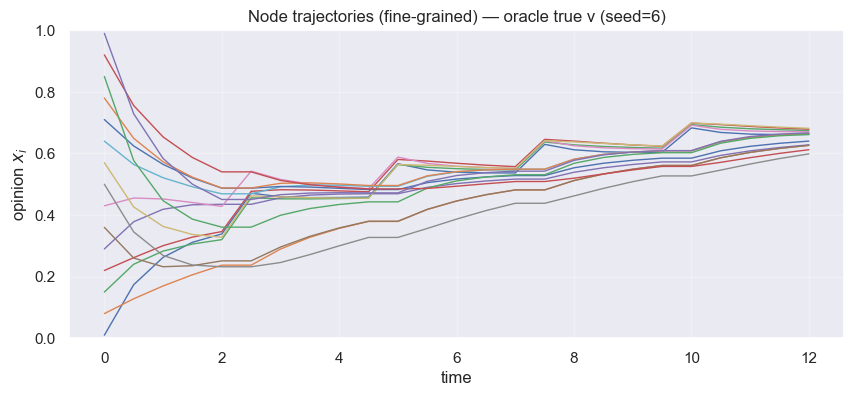

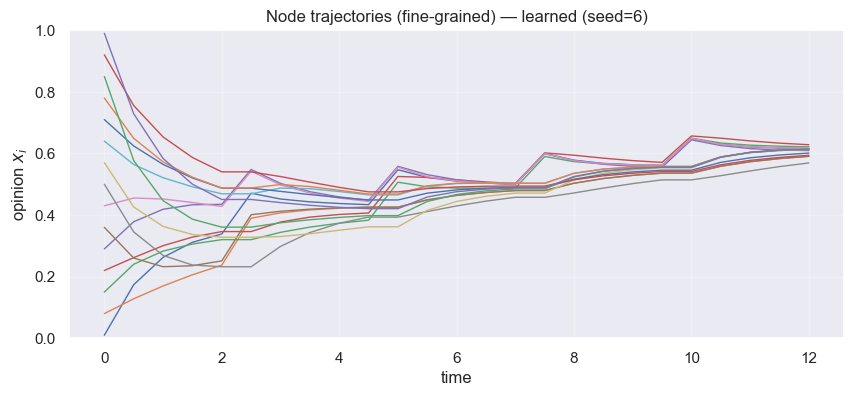


=== CENTRALITY COMPARISON (by node index) ===
L1(v_hat - v_true): 0.6099919752112599


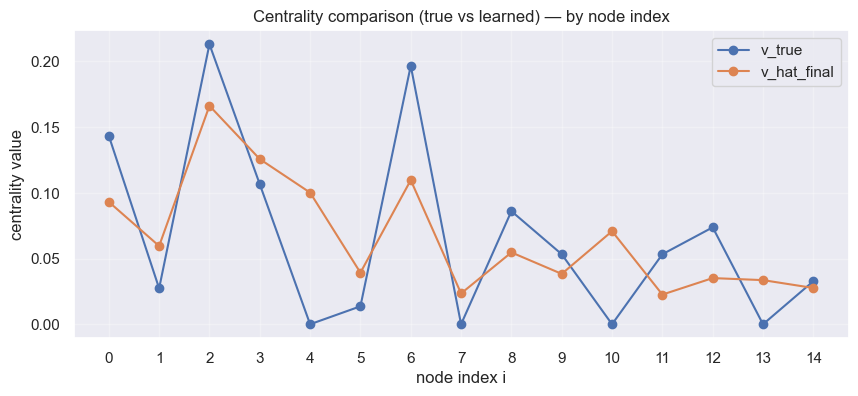

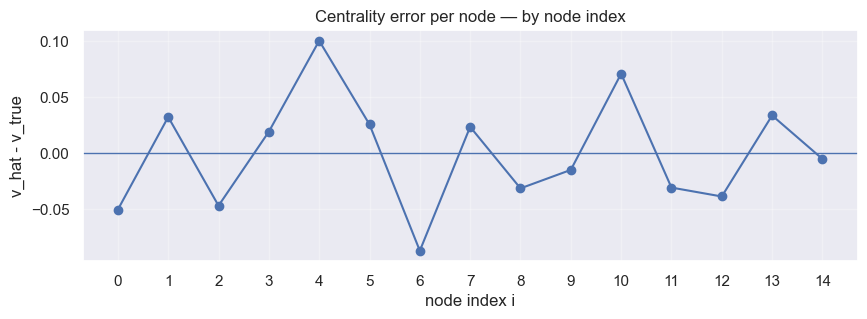

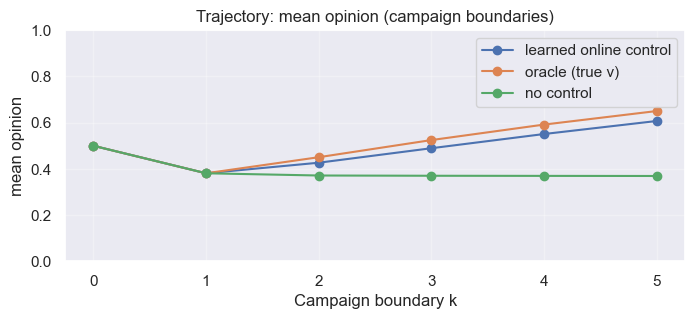

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from rl_envs_forge.envs.network_graph.graph_utils import compute_laplacian, compute_eigenvector_centrality

from opinion_dynamics.experiments.plots import (
    plot_impulse_node_trajectories,
    show_matrix_with_cell_grid,
    concat_intermediate
)
from opinion_dynamics.experiments.metrics import graph_sanity
from opinion_dynamics.experiments.rollouts import rollout_with_v_intermediate
from opinion_dynamics.experiments.online import run_single_seed_experiment


SEED_TO_PLOT = 6
B_campaign = 1.0
num_campaigns_total = 5

metrics, art = run_single_seed_experiment(
    seed=SEED_TO_PLOT,
    B_campaign=B_campaign,
    num_campaigns_total=num_campaigns_total,
    lr=1e-3,
    l2_lambda=0.0,
    device="cpu",
    update_A_each_campaign=True,
    suppress_fit_logs=True,
    return_artifacts=True,
)

print("=== METRICS ===")
print(metrics)

env = art["env"]

# -----------------------------
# True graph + v_true (env-consistent)
# -----------------------------
A_true = np.asarray(art["A_true"], dtype=float)
v_true = np.asarray(art["v_true"], dtype=float)

A_hat_final = np.asarray(art["A_hat_final"], dtype=float)
v_hat_final = np.asarray(art["v_hat_final"], dtype=float)

# -----------------------------
# GRAPH SANITY
# -----------------------------
print("\n=== GRAPH SANITY (TRUE) ===")
for k, v in graph_sanity(A_true).items():
    print(f"{k}: {v}")

print("\n=== GRAPH SANITY (LEARNED FINAL) ===")
for k, v in graph_sanity(A_hat_final).items():
    print(f"{k}: {v}")

# -----------------------------
# Heatmaps (true vs learned-final)
# -----------------------------
show_matrix_with_cell_grid(A_true,      title=f"True A (seed={SEED_TO_PLOT})")
show_matrix_with_cell_grid(A_hat_final, title=f"Learned A_hat final (seed={SEED_TO_PLOT})")

# -----------------------------
# Learned run: fine-grained impulse trajectories
# (this is what your plot_impulse_node_trajectories expects)
# -----------------------------
inter_list = art["intermediate_states_list"]   # list length K, each (T_k, N)
time_list  = art["intermediate_times_list"]    # list length K, each (T_k,)

valid_pairs = [(xs, ts) for xs, ts in zip(inter_list, time_list) if xs is not None and ts is not None]
if not valid_pairs:
    raise RuntimeError("No intermediate trajectories found. env.step must return info['intermediate_states'].")

lengths = [xs.shape[0] for xs, _ in valid_pairs]
same_len = all(L == lengths[0] for L in lengths)

if same_len:
    inter_learn = np.stack([xs for xs, _ in valid_pairs], axis=0)   # (K, T, N)
    times_learn = np.stack([ts for _, ts in valid_pairs], axis=0)   # (K, T)
else:
    # If lengths differ per campaign, we can't stack into (K,T,N).
    # We'll plot per-campaign instead.
    inter_learn = None
    times_learn = None

# -----------------------------
# Oracle + no-control rollouts WITH intermediate (using new function)
# -----------------------------
states_learn = np.asarray(art["states_learn"], dtype=float)
x0 = art["x0"]
K_total = states_learn.shape[0] - 1  # campaigns actually run

or_out = rollout_with_v_intermediate(env, x0, K_total, B_campaign, v_true)
nc_out = rollout_with_v_intermediate(env, x0, K_total, B_campaign, None)

# -----------------------------
# Oracle + no-control rollouts WITH intermediate
# -----------------------------
states_learn = np.asarray(art["states_learn"], dtype=float)
x0 = art["x0"]
K_total = states_learn.shape[0] - 1

or_out = rollout_with_v_intermediate(env, x0, K_total, B_campaign, v_true, zero_first_campaign=True)
nc_out = rollout_with_v_intermediate(env, x0, K_total, B_campaign, None,   zero_first_campaign=True)

# -----------------------------
# Concatenate to (T_total,N) so plot_impulse_node_trajectories behaves
# -----------------------------
dt = getattr(env, "t_s", None)

X_or, T_or = concat_intermediate(
    or_out["intermediate_states_list"],
    or_out["intermediate_times_list"],
    dt=dt,
)

X_le, T_le = concat_intermediate(
    art["intermediate_states_list"],
    art["intermediate_times_list"],
    dt=dt,
)

plot_impulse_node_trajectories(X_or, T_or, title=f"Node trajectories (fine-grained) — oracle true v (seed={SEED_TO_PLOT})")
plot_impulse_node_trajectories(X_le, T_le, title=f"Node trajectories (fine-grained) — learned (seed={SEED_TO_PLOT})")

# -----------------------------
# Centrality comparison plots (like your simple experiment)
# -----------------------------
print("\n=== CENTRALITY COMPARISON (by node index) ===")
print("L1(v_hat - v_true):", float(np.sum(np.abs(v_hat_final - v_true))))

idx = np.arange(len(v_true))
diff = v_hat_final - v_true

plt.figure(figsize=(10, 4))
plt.plot(idx, v_true, marker="o", label="v_true")
plt.plot(idx, v_hat_final, marker="o", label="v_hat_final")
plt.xlabel("node index i")
plt.ylabel("centrality value")
plt.title("Centrality comparison (true vs learned) — by node index")
plt.xticks(idx)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 3))
plt.axhline(0.0, linewidth=1)
plt.plot(idx, diff, marker="o")
plt.xlabel("node index i")
plt.ylabel("v_hat - v_true")
plt.title("Centrality error per node — by node index")
plt.xticks(idx)
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------
# Mean opinion plot (campaign boundaries)
# -----------------------------
states_oracle = np.asarray(or_out["states"], dtype=float)
states_noc    = np.asarray(nc_out["states"], dtype=float)

mean_learn = states_learn.mean(axis=1)
mean_or    = states_oracle.mean(axis=1)
mean_nc    = states_noc.mean(axis=1)

plt.figure(figsize=(8, 3))
plt.plot(mean_learn, marker="o", label="learned online control")
plt.plot(mean_or, marker="o", label="oracle (true v)")
plt.plot(mean_nc, marker="o", label="no control")
plt.xlabel("Campaign boundary k")
plt.ylabel("mean opinion")
plt.title("Trajectory: mean opinion (campaign boundaries)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0, 1)
plt.show()